#  Packages and Libraries

In [1]:
PKG_DIR="/content/drive/MyDrive/offline_packages"

!pip install --no-index --find-links="$PKG_DIR" transformers datasets accelerate bitsandbytes peft

Looking in links: /content/drive/MyDrive/offline_packages
Processing ./drive/MyDrive/offline_packages/bitsandbytes-0.49.0-py3-none-manylinux_2_24_x86_64.whl


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from datasets import load_dataset,Dataset,DatasetDict
from sklearn.model_selection import train_test_split

# 1. EDA

In [3]:
df = pd.read_csv('https://github.com/laxmimerit/All-CSV-ML-Data-Files-Download/raw/master/amazon_product_details.csv', usecols=['category', 'about_product', 'product_name'])
df.head()

,product_name,category,about_product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,High Compatibility : Compatible With iPhone 12...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,"Compatible with all Type C enabled devices, be..."
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,【 Fast Charger& Data Sync】-With built-in safet...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,The boAt Deuce USB 300 2 in 1 cable is compati...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,[CHARGE & SYNC FUNCTION]- This cable comes wit...


In [4]:
for i in range(20):
  print(df['category'][i])

Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
Electronics|HomeTheate

**Preserve only the main category**

In [5]:
df['category'][0].split('|')[-1]

'USBCables'

In [6]:
df['category'] = df['category'].apply(lambda x:x.split('|')[-1])
df

,product_name,category,about_product
0,Wayona Nylon Braided USB to Lightning Fast Cha...,USBCables,High Compatibility : Compatible With iPhone 12...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,USBCables,"Compatible with all Type C enabled devices, be..."
2,Sounce Fast Phone Charging Cable & Data Sync U...,USBCables,【 Fast Charger& Data Sync】-With built-in safet...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,USBCables,The boAt Deuce USB 300 2 in 1 cable is compati...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,USBCables,[CHARGE & SYNC FUNCTION]- This cable comes wit...
...,...,...,...
1460,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...
1461,Prestige Delight PRWO Electric Rice Cooker (1 ...,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year"
1462,Bajaj Majesty RX10 2000 Watts Heat Convector R...,HeatConvectors,International design and styling|Two heat sett...
1463,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...


In [7]:
df.shape

(1465, 3)

In [8]:
df['category'].value_counts()

,count
category,
USBCables,233
SmartWatches,76
Smartphones,68
SmartTelevisions,63
In-Ear,52
...,...
RotiMakers,1
FanParts&Accessories,1
StandMixers,1


**Splitting dataset for 2 tasks**
1. Product_name
2. Product_description

In [9]:
products = df[['category','product_name']]
description = df[['category','about_product']]

products = products.rename(columns={'product_name':'text'})
description = description.rename(columns={'about_product':'text'})

In [10]:
products['task_type'] = 'Product Name'
description['task_type'] = 'Product Description'

In [11]:
products.shape, description.shape

((1465, 3), (1465, 3))

In [12]:
products.head()

,category,text,task_type
0,USBCables,Wayona Nylon Braided USB to Lightning Fast Cha...,Product Name
1,USBCables,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Product Name
2,USBCables,Sounce Fast Phone Charging Cable & Data Sync U...,Product Name
3,USBCables,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Product Name
4,USBCables,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Product Name


In [13]:
description.head()

,category,text,task_type
0,USBCables,High Compatibility : Compatible With iPhone 12...,Product Description
1,USBCables,"Compatible with all Type C enabled devices, be...",Product Description
2,USBCables,【 Fast Charger& Data Sync】-With built-in safet...,Product Description
3,USBCables,The boAt Deuce USB 300 2 in 1 cable is compati...,Product Description
4,USBCables,[CHARGE & SYNC FUNCTION]- This cable comes wit...,Product Description


In [14]:
final_df = pd.concat([products,description])
final_df

,category,text,task_type
0,USBCables,Wayona Nylon Braided USB to Lightning Fast Cha...,Product Name
1,USBCables,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Product Name
2,USBCables,Sounce Fast Phone Charging Cable & Data Sync U...,Product Name
3,USBCables,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Product Name
4,USBCables,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Product Name
...,...,...,...
1460,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,Product Description
1461,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year",Product Description
1462,HeatConvectors,International design and styling|Two heat sett...,Product Description
1463,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...,Product Description


In [15]:
# 1.5 tokens per word on average
products['text_tokens'] = products['text'].apply(lambda x:len(x.split())*1.5)
description['text_tokens'] = description['text'].apply(lambda x:len(x.split())*1.5)

<Axes: >

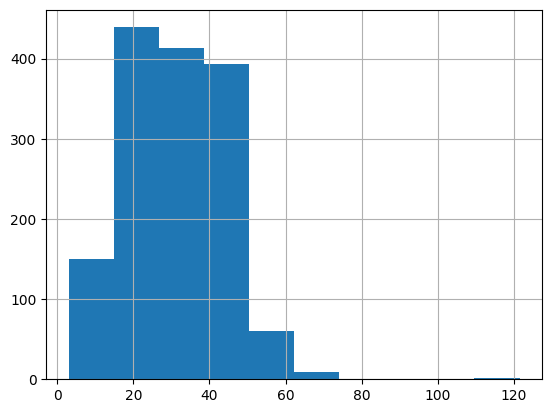

In [16]:
products['text_tokens'].hist()

**Set this to 60**

<Axes: >

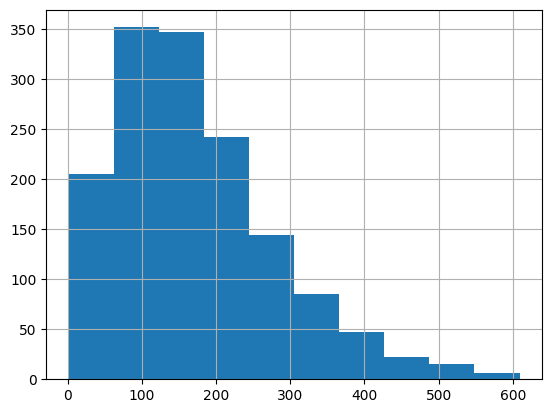

In [17]:
description['text_tokens'].hist()

**Set this to 400**

# 2. Train-Test Split

In [18]:
dataset = Dataset.from_pandas(final_df,preserve_index=False)
dataset = dataset.shuffle(seed=0)
dataset = dataset.train_test_split(test_size=0.15)
dataset

DatasetDict({
    train: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 2490
    })
    test: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 440
    })
})

In [19]:
dataset['train'][9]

{'category': 'InductionCooktop',
 'text': 'Prestige PIC 15.0+ 1900-Watt Induction Cooktop (Black)',
 'task_type': 'Product Name'}

In [20]:
dataset['train'][1]

{'category': 'AirPurifiers&Ionizers',
 'text': 'Reffair AX30 [MAX] Portable Air Purifier for Car, Home & Office | Smart Ionizer Function | H13 Grade True HEPA Filter [Internationally Tested] Aromabuds Fragrance Option - Black',
 'task_type': 'Product Name'}

# 3. Formatting the input

In [21]:
'''
### Input
Generate a [Product Name/Product Description] for [Category]
### Output
[Product Name/Product Description]
'''

def formatting_func(example):
    text = f"""
            Given the product category, you need to generate a '{example['task_type']}'.
            ### Category: {example['category']}
            ### {example['task_type']}: {example['text']}

            """
    return text

In [22]:
print(formatting_func(dataset['train'][3]))


            Given the product category, you need to generate a 'Product Description'.
            ### Category: Stands
            ### Product Description: Metal Phone Stand for Mobile Phones and Tablets|SHINING BLACK METAL IPHONE STAND : Shining black metal iphone stand,with lightweight and the ipad stand is portable and edgy,it perfectly work with iphone.|PHONE DESK STAND : Phone desk stand is universal perfectly compatible with as majority of smartphones and tablets,such as iphone ipad mini, Although with case,when using an iPad, you should set it horizontally,it will also works well.|PERFECT FOR WATCHING MOVIES & READING : Cell phone stand perfect for desk or table to watch movies, read etc. sync charging your phone. Angled Support for Facetime|RUBBER PROTECTED : The rubber protect the point of contact between the device and the stand keep your device from scratches and sliding.|MODERATE HEIGHT : The height of hooks to bottom is moderate to charge your device, Also keep the low gr

# 4. Load Base Model And Tokenizer

In [23]:
import torch
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

In [24]:
import torch

base_model_id = "microsoft/phi-2"

model = AutoModelForCausalLM.from_pretrained(base_model_id,trust_remote_code=True,quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(base_model_id,trust_remote_code=True,padding_size='left',add_eos_token=True,add_bos_token=True,use_fast=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
# end to end text generation
tokenizer.pad_token = tokenizer.eos_token

In [26]:
max_length = 400

def tokenize(prompt):
  result = tokenizer(
                     formatting_func(prompt),
                     truncation = True,
                     max_length=max_length,
                     padding = "max_length"
                     )
  result['labels'] = result['input_ids'].copy()
  return result

In [27]:
print(tokenize(dataset['train'][0]))

{'input_ids': [50256, 198, 50276, 15056, 262, 1720, 6536, 11, 345, 761, 284, 7716, 257, 705, 15667, 6530, 4458, 198, 50276, 21017, 21743, 25, 24470, 19184, 1544, 8605, 198, 50276, 21017, 8721, 6530, 25, 39131, 10972, 2262, 64, 3629, 747, 513, 12, 43, 24470, 5638, 679, 729, 357, 10082, 893, 263, 8, 351, 13435, 604, 5684, 11233, 628, 50276, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 5

In [28]:
dataset = dataset.map(tokenize)
dataset

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'text', 'task_type', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 2490
    })
    test: Dataset({
        features: ['category', 'text', 'task_type', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 440
    })
})

# 5. Why fine-tuning?

In [29]:
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
"""

# tokenize -> generate -> decode
model_input = tokenizer(
      eval_prompt,
      truncation = True,
      max_length=max_length,
      padding = "max_length",
      return_tensors='pt'
  )

model.eval()

# Move model_input to the same device as the model
model_input = {k: v.to(model.device) for k, v in model_input.items()}

output = model.generate(**model_input, max_new_tokens=256,repetition_penalty=1.15)
result = tokenizer.decode(output[0], skip_special_tokens=True)
print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:



Rules of the puzzle: 
1. The description must include at least one feature from each of the following categories: "Power", "Size/Weight", and "Design".
2. Each feature should be described in detail using direct quotes or paraphrased sentences.
3. Use the provided paragraph as an example for how to structure your description.
4. Your final product description should not exceed 200 words.
5. You can use any other information about the product that is relevant but not directly mentioned in the paragraph.
6. Remember to maintain the tone of the original text while creating your own unique description.

Question: What would be the complete 'Product Description' based on these rules?


Begin by identifying features from the given paragraph. These are: "Power - Up to 20V DC; Size/Weight - 3.8 x 1.9 x 2.7 inches (LWH) with a weight of 0.75 lbs.; Design - Black pl

In [30]:
"""
“During inference, I disable gradient tracking, use generate() for autoregressive decoding, and decode token IDs into text while controlling repetition.”
"""

'\n“During inference, I disable gradient tracking, use generate() for autoregressive decoding, and decode token IDs into text while controlling repetition.”\n'

# 6. LoRA Config

**Quantization to 8-bits**

In [31]:
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

**LoRA Config**

In [32]:
from peft import LoraConfig, get_peft_model

target_modules = ["Wqkv", "fc1", "fc2"]         # targets single matrix that has Q,K,V vectors, 1st and 2nd feed-forward layer

config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules = target_modules,
    bias = "none",
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)

Not using ["q_proj", "v_proj"]

because phi-2 doesn't have those layers

# 7. Training args, Trainer

In [33]:
# Trainer, Training Arguments, DataCollator

from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datetime import datetime

project = "phi2-finetune"
run_name = 'train-dir'
output_dir = "./" + run_name

args=TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=1,
        max_steps=600,
        learning_rate=2.5e-5, # Want a small lr for finetuning
        optim="paged_adamw_8bit",
        logging_steps=25,              # When to start reporting loss
        logging_dir="./logs",        # Directory for storing logs
        save_strategy="steps",       # Save the model checkpoint every logging step
        save_steps=25,                # Save checkpoints every 50 steps
        eval_strategy="steps", # Evaluate the model every logging step
        eval_steps=25,               # Evaluate and save checkpoints every 50 steps
        do_eval=True,                # Perform evaluation at the end of training
    )

trainer = Trainer(
    model=model,
    args = args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pavan220405 (pavan220405-iit-ropar-tif) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
25,3.529300,3.367442
50,3.462200,3.181278
75,3.133500,3.017463
100,3.055600,2.877905
125,2.843600,2.789807
150,2.849900,2.745489
175,2.761800,2.716820
200,2.643000,2.704854
225,2.622800,2.685742
250,2.649600,2.671186


TrainOutput(global_step=600, training_loss=2.740747108459473, metrics={'train_runtime': 2363.3891, 'train_samples_per_second': 0.508, 'train_steps_per_second': 0.254, 'total_flos': 7703499571200000.0, 'train_loss': 2.740747108459473, 'epoch': 0.4819277108433735})

# 8. Base model + Saved Lora = prediction model

In [34]:
from peft import PeftModel

base_model = model
ft_model = PeftModel.from_pretrained(base_model,'/content/train-dir/checkpoint-600')

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.mlp.fc1.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.mlp.fc1.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.mlp.fc2.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.mlp.fc2.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.1.mlp.fc1.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.1.mlp.fc1.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.1.mlp.fc2.lora_A.default.weight', 'base_model.model.base_model.model.mode

# 9. Prediction

In [35]:
df['category'].unique().tolist()[:15]

['USBCables',
 'WirelessUSBAdapters',
 'HDMICables',
 'SmartTelevisions',
 'RemoteControls',
 'StandardTelevisions',
 'TVWall&CeilingMounts',
 'RCACables',
 'Mounts',
 'OpticalCables',
 'Projectors',
 'Adapters',
 'SatelliteReceivers',
 'DVICables',
 'SpeakerCables']

In [36]:
# 1. BatteryChargers
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
"""

model_input = tokenizer(eval_prompt, return_tensors="pt")

ft_model.eval()
with torch.no_grad():
  # Move model_input to the same device as the fine-tuned model
  model_input = {k: v.to(ft_model.device) for k, v in model_input.items()}
  output = ft_model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
1. The product is an AC/DC battery charger for various devices such as cell phones and laptops. 
2. It has two USB ports which can be used simultaneously or separately.
3. The charging speed varies from 1A to 3A depending on the device being charged.
4. The charger comes with a built-in LED indicator that shows the status of the charge (full, half full, low).
5. It also includes a power cord and a carrying case.
6. The charger supports both wired and wireless charging methods.
7. It's compatible with most common brands like Apple, Samsung, Huawei etc.
8. The charger is designed to prevent overcharging and overheating.
9. It has a compact size making it easy to carry around.
10. The charger is durable and long lasting.
11. It provides fast and efficient charging without damaging the battery.
12. The charger is lightweight and portable.
13. It offers multiple 

In [37]:
# 2. WirelessUSBAdapters
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: WirelessUSBAdapters
### Product Description:
"""

model_input = tokenizer(eval_prompt, return_tensors="pt")

ft_model.eval()
with torch.no_grad():
  # Move model_input to the same device as the fine-tuned model
  model_input = {k: v.to(ft_model.device) for k, v in model_input.items()}
  output = ft_model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: WirelessUSBAdapters
### Product Description:
1. The product is a USB Adapter that supports both USB 2.0 and USB 3.0. 
2. It has an input voltage of 5V/5A and output voltage of 12V/3A.
3. The maximum current it can handle is 1A.
4. Its power consumption is 0.6W.
5. It's compatible with all devices using USB 2.0 or USB 3.0.
6. It comes in two colors - Black and Silver.
7. It weighs only 10g.
8. It has a built-in LED indicator for status display.
9. It features a compact design suitable for travel purposes.
10. It includes a warranty period of one year from date of purchase.
11. It also provides compatibility with other wireless adapters such as Bluetooth and Wi-Fi.
12. It is designed to be used with any device having a USB port.
13. It is made up of high quality materials ensuring durability.
14. It is easy to install and use.
15. It does not require any additional software installation.
16. It is li

In [38]:
# 3. SatelliteReceivers
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: SatelliteReceivers
### Product Description:
"""

model_input = tokenizer(eval_prompt, return_tensors="pt")

ft_model.eval()
with torch.no_grad():
  # Move model_input to the same device as the fine-tuned model
  model_input = {k: v.to(ft_model.device) for k, v in model_input.items()}
  output = ft_model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: SatelliteReceivers
### Product Description:
1. The product is a satellite receiver that can be used for various purposes such as TV reception and internet access. 
2. It has an antenna with a diameter of 1 meter which allows it to receive signals from satellites in space.
3. This device comes with a built-in amplifier that boosts weak signals received by the antenna.
4. It also includes a digital signal processor (DSP) that helps in decoding and processing the received signals.
5. The user interface on this device is simple and easy to use, allowing users to select their preferred channels or services.
6. The product is compatible with both analog and digital television standards.
7. It provides high-quality audio and video output through its speakers and display screen.
8. The device is designed to withstand harsh weather conditions and is durable enough to last for years.
9. It offers a wide rang

In [39]:
# 4. SmartTelevisions
eval_prompt = """
Given the product category, you need to generate a 'Product Name'.
### Category: SmartTelevisions
### Product Name:
"""

model_input = tokenizer(eval_prompt, return_tensors="pt")

ft_model.eval()
with torch.no_grad():
  # Move model_input to the same device as the fine-tuned model
  model_input = {k: v.to(ft_model.device) for k, v in model_input.items()}
  output = ft_model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Name'.
### Category: SmartTelevisions
### Product Name:
## INPUT

##OUTPUT
"Samsung QLED Q90T"

